# Sanskrit to English Translation using NLLB-200

In [1]:
# 1. Environment Setup
!pip install transformers datasets torch pandas nltk sentencepiece accelerate

In [5]:
# 2. Import Libraries and Initialize Local Model/Tokenizer
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments

MODEL_NAME = "facebook/nllb-200-distilled-600M"

# Load local tokenizer and model weights
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang="san_Deva", tgt_lang="eng_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [6]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments

MODEL_NAME = "facebook/nllb-200-distilled-600M"

# Load local tokenizer and model weights
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang="san_Deva", tgt_lang="eng_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)


class NLLBTranslationDataset(Dataset):
    def __init__(self, df, tokenizer, src_col="Sentence_sa", tgt_col="Sentence_en", max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.src_col = src_col
        self.tgt_col = tgt_col
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src_text = str(row[self.src_col])
        tgt_text = str(row[self.tgt_col])

        # Tokenize source text
        model_inputs = self.tokenizer(
            src_text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        # Tokenize target text using text_target
        labels = self.tokenizer(
            text_target=tgt_text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        labels_ids = labels["input_ids"].squeeze(0)
        labels_ids[labels_ids == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": model_inputs["input_ids"].squeeze(0),
            "attention_mask": model_inputs["attention_mask"].squeeze(0),
            "labels": labels_ids
        }


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [7]:
# 4. Load Data and Instantiate Datasets
import os

DATA_DIR = "data"
RESULT_DIR = "result"
os.makedirs(RESULT_DIR, exist_ok=True)

# Training data from data/
train_sa = pd.read_csv(os.path.join(DATA_DIR, "train_sa_10000.csv"))
train_en = pd.read_csv(os.path.join(DATA_DIR, "train_en_10000.csv"))
train_df = train_sa.merge(train_en, on="Source_id")

# Dev and test data from data/
dev_sa = pd.read_csv(os.path.join(DATA_DIR, "dev_sa_1000.csv"))
dev_en = pd.read_csv(os.path.join(DATA_DIR, "dev_en_1000.csv"))
dev_df = dev_sa.merge(dev_en, on="Source_id")

test_sa = pd.read_csv(os.path.join(DATA_DIR, "test_sa_1000.csv"))
test_en = pd.read_csv(os.path.join(DATA_DIR, "test_en_1000.csv"))
test_df = test_sa.merge(test_en, on="Source_id")

print(f"Train: {len(train_df)}, Dev: {len(dev_df)}, Test: {len(test_df)}")

train_dataset = NLLBTranslationDataset(train_df, tokenizer)
dev_dataset = NLLBTranslationDataset(dev_df, tokenizer)

Train: 10000, Dev: 1000, Test: 1000


In [8]:
# 5. Setup Local Training Pipeline
import transformers
print(f"transformers version: {transformers.__version__}")

try:
    training_args = Seq2SeqTrainingArguments(
        output_dir="./nllb_sanskrit_english",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        weight_decay=0.01,
        save_total_limit=2,
        num_train_epochs=3,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="none"
    )
except TypeError:
    training_args = Seq2SeqTrainingArguments(
        output_dir="./nllb_sanskrit_english",
        evaluation_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        weight_decay=0.01,
        save_total_limit=2,
        num_train_epochs=3,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to="none"
    )

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
)

trainer.train()

transformers version: 5.12.1


Epoch,Training Loss,Validation Loss
1,1.591728,1.499278
2,1.462478,1.441688
3,1.345159,1.430211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3750, training_loss=1.515789998372396, metrics={'train_runtime': 3482.2078, 'train_samples_per_second': 8.615, 'train_steps_per_second': 1.077, 'total_flos': 8126642257920000.0, 'train_loss': 1.515789998372396, 'epoch': 3.0})

In [10]:
# 6. Generate Submission File
def generate_translations(test_df, model, tokenizer, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.to(device)
    model.eval()
    predictions = []

    for idx, row in test_df.iterrows():
        src_text = str(row["Sentence_sa"])
        inputs = tokenizer(src_text, return_tensors="pt", padding=True, truncation=True).to(device)
        # Fix: Use convert_tokens_to_ids instead of lang_code_to_id
        forced_bos_token_id = tokenizer.convert_tokens_to_ids("eng_Latn")

        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                max_length=128
            )

        translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
        predictions.append(translation)

    submission_df = pd.DataFrame({
        "Source_id": test_df["Source_id"],
        "Sentence_en": predictions
    })

    output_path = os.path.join(RESULT_DIR, "submission.csv")
    submission_df.to_csv(output_path, index=False, encoding="utf-8")
    print(f"submission.csv saved to {output_path}")

generate_translations(test_df, model, tokenizer)

submission.csv saved to result/submission.csv


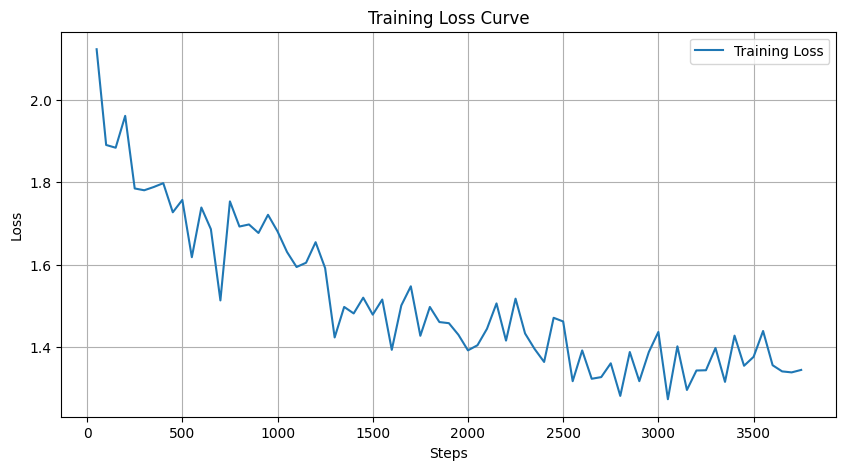

Evaluating 10 samples...
BLEU Score: 0.2834


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore (F1) Mean: 0.9356
submission.csv saved to result/submission.csv
Inference Efficiency: 0.6034 seconds per sentence

--- Translation Examples ---
Example 1:
  Source (SA): एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
  Ref (EN):    Eclipse also helps the programmer to find out errors.
  Pred (EN):   Eclipse also helps in troubleshooting for the programmer.
------------------------------
Example 2:
  Source (SA): विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
  Ref (EN):    "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
  Pred (EN):   "Wherefore I say of faith, Speak: and we have the same spirit of faith, as it is written, And believe, and say."
------------------------------
Example 3:
  Source (SA): तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि न

In [16]:
!pip install evaluate bert_score
import matplotlib.pyplot as plt
import time
import pandas as pd
import os
from evaluate import load

# 1. Plot Training Curve
if 'trainer' in globals() and hasattr(trainer, 'state') and trainer.state.log_history:
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    steps = [x['step'] for x in history if 'loss' in x]

    if train_loss:
        plt.figure(figsize=(10, 5))
        plt.plot(steps, train_loss, label='Training Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.legend()
        plt.grid(True)
        plt.show()

# 2. Detailed Metrics (BLEU & BERTScore)
bleu = load("bleu")
bertscore = load("bertscore")

# Load the full set of predictions
references = test_df["Sentence_en"].tolist()
pred_df = pd.read_csv(os.path.join(RESULT_DIR, "submission.csv"))
predictions = pred_df["Sentence_en"].fillna("").tolist()

# Fix: Align lengths if they mismatch to prevent the ValueError
min_len = min(len(predictions), len(references))
if len(predictions) != len(references):
    print(f"Warning: Length mismatch. Evaluating first {min_len} samples.")
    eval_preds = predictions[:min_len]
    eval_refs = references[:min_len]
else:
    eval_preds = predictions
    eval_refs = references

print(f"Evaluating {len(eval_preds)} samples...")

# BLEU
bleu_results = bleu.compute(predictions=eval_preds, references=[[r] for r in eval_refs])
print(f"BLEU Score: {bleu_results['bleu']:.4f}")

# BERTScore
bert_results = bertscore.compute(predictions=eval_preds, references=eval_refs, lang="en")
print(f"BERTScore (F1) Mean: {sum(bert_results['f1'])/len(bert_results['f1']):.4f}")

# 3. Efficiency
start_time = time.time()
_ = generate_translations(test_df.head(10), model, tokenizer)
duration = time.time() - start_time
print(f"Inference Efficiency: {duration/10:.4f} seconds per sentence")

# 4. 5 Examples
print("\n--- Translation Examples ---")
for i in range(min(5, len(eval_preds))):
    print(f"Example {i+1}:")
    print(f"  Source (SA): {test_df.iloc[i]['Sentence_sa']}")
    print(f"  Ref (EN):    {eval_refs[i]}")
    print(f"  Pred (EN):   {eval_preds[i]}")
    print("-" * 30)